In [17]:
%autosave 60

Autosaving every 60 seconds


In [27]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from bert_score import score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine
from sentence_transformers import SentenceTransformer

In [3]:
with open('texts.txt', 'r') as file:
    texts = file.readlines()

In [4]:
texts = np.array([i.strip() for i in texts])

In [6]:
model_path = 'Qwen3-Embedding-0.6B'

# подход 1: cosine similarity

In [7]:
model = SentenceTransformer(model_path)

In [8]:
# оригинальный текст, для которого я буду искать похожие чанки
text_init = """
максим шаланкин, data science team lead, мтс  automl в действии: автоматизация ml-экспериментов для бизнес-команд  мы представим опыт создания платформы automl, расширившей возможности кросс-функциональной команды в быстрой проработке бизнес-гипотез. платформа позволяет строить и скорить табличные ml модели в простом интерфейсе. ключевая задача: демократизация доступа к ml для бизнес-пользователей без глубоких знаний в data science, ускорение проверки гипотез и запуска экспериментов.  подробно остановимся на следующих аспектах: преодоление скептицизма и построение доверия: стратегии и тактики, которые мы использовали для убеждения product owner и data analyst в эффективности и надежности автоматизированного подхода к ml; образовательный аспект внедрения automl: как мы решали задачу обучения пользователей с минимальными знаниями в ml и делали платформу интуитивно понятной; оптимизация ресурсов и демократизация ml: как automl платформа разгрузила backlog разработчиков и открыла доступ к ml-решениям для команд без собственных data scientists. измеримые результаты и метрики: конкретные примеры успешных кейсов, метрики эффективности и влияние на бизнес-процессы компании; что нужно делать вам чтобы повторить наш успех.  слушатели переосмыслят подход к проверке бизнес-гипотез с ml, узнают, как преодолевать сопротивление при внедрении автоматизации, получат инсайты по планированию ресурсов для подобных проектов, ознакомятся с метриками оценки эффективности automl решений, узнают о потенциальных трудностях и способах их преодоления
"""

embedding_init = model.encode(text_init)

In [9]:
embeddings = []

for text in tqdm(texts):
    embeddings.append(model.encode(text))

100%|██████████| 76/76 [00:43<00:00,  1.75it/s]


In [70]:
distances = [cosine(embedding_init, i) for i in embeddings]

In [71]:
for idx, text in enumerate(texts[np.argsort(distances)][: 4]):
    print(f'Похожий текст №{idx+1}\n\n{text}\n\n***')

Похожий текст №1

максим шаланкин, data science team lead, мтс  automl в действии: автоматизация ml-экспериментов для бизнес-команд  мы представим опыт создания платформы automl, расширившей возможности кросс-функциональной команды в быстрой проработке бизнес-гипотез. платформа позволяет строить и скорить табличные ml модели в простом интерфейсе. ключевая задача: демократизация доступа к ml для бизнес-пользователей без глубоких знаний в data science, ускорение проверки гипотез и запуска экспериментов.  подробно остановимся на следующих аспектах: преодоление скептицизма и построение доверия: стратегии и тактики, которые мы использовали для убеждения product owner и data analyst в эффективности и надежности автоматизированного подхода к ml; образовательный аспект внедрения automl: как мы решали задачу обучения пользователей с минимальными знаниями в ml и делали платформу интуитивно понятной; оптимизация ресурсов и демократизация ml: как automl платформа разгрузила backlog разработчиков и

# подход 2: bert score

In [72]:
# соберем все метрики, но будем использовать только f1
metrics = [
    [
        metric.numpy()[0] 
        for metric in score(
            cands=[text_init],
            refs=[i],
            model_type=model_path,
            num_layers=20,
            lang="ru",
            verbose=False,
        )
    ] for i in tqdm(texts)
]

100%|██████████| 76/76 [01:58<00:00,  1.56s/it]


In [73]:
metrics_f1 = np.array([i[2] for i in metrics])

In [74]:
n_limit = 4
for idx, (text, value) in enumerate(
    zip(texts[np.argsort(metrics_f1)[::-1]][: n_limit], metrics_f1[np.argsort(metrics_f1)[::-1]][: n_limit])
):
    print(f'Похожий текст №{idx+1}; value: {value:0.3f}\n\n{text}\n\n***')

Похожий текст №1; value: 1.000

максим шаланкин, data science team lead, мтс  automl в действии: автоматизация ml-экспериментов для бизнес-команд  мы представим опыт создания платформы automl, расширившей возможности кросс-функциональной команды в быстрой проработке бизнес-гипотез. платформа позволяет строить и скорить табличные ml модели в простом интерфейсе. ключевая задача: демократизация доступа к ml для бизнес-пользователей без глубоких знаний в data science, ускорение проверки гипотез и запуска экспериментов.  подробно остановимся на следующих аспектах: преодоление скептицизма и построение доверия: стратегии и тактики, которые мы использовали для убеждения product owner и data analyst в эффективности и надежности автоматизированного подхода к ml; образовательный аспект внедрения automl: как мы решали задачу обучения пользователей с минимальными знаниями в ml и делали платформу интуитивно понятной; оптимизация ресурсов и демократизация ml: как automl платформа разгрузила backlog р

## Проверка пересечения топов
заодно посмотрим, одинаково ли работают эти два подхода - через оценку пересечения

In [24]:
overlaps = []
for idx in range(1, len(distances) + 1):
    set_1 = set(np.argsort(distances)[: idx])
    set_2 = set(np.argsort(metrics_f1)[::-1][: idx])

    overlaps.append(len(set_1.intersection(set_2)) / len(set_1.union(set_2)))

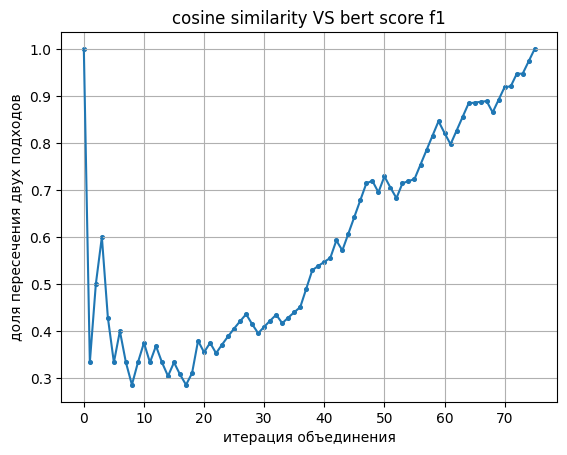

In [25]:
plt.scatter(range(len(overlaps)), overlaps, s=7)
plt.plot(range(len(overlaps)), overlaps)

plt.xlabel('итерация объединения')
plt.ylabel('доля пересечения двух подходов')

plt.grid()
plt.title('cosine similarity VS bert score f1')
plt.show()

# Визуализация докладов

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import mplcyberpunk

In [76]:
plt.style.use("cyberpunk")

In [77]:
embs_2d = PCA(n_components=2).fit_transform(embeddings)

In [78]:
bert_indices = np.argsort(metrics_f1)[::-1][: 10]
cosine_indices = np.argsort(distances)[: 10]
bert_center = embs_2d[bert_indices].mean(axis=0)
cosine_center = embs_2d[cosine_indices].mean(axis=0)
global_center = embs_2d.mean(axis=0)

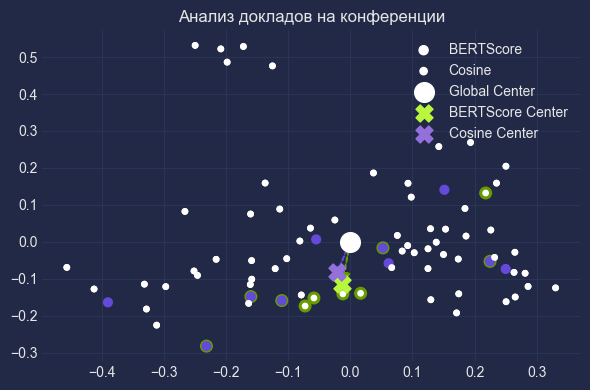

In [87]:
plt.figure(figsize=(6, 4))


plt.scatter(
    embs_2d[:, 0], embs_2d[:, 1],
    color=[('#679B00' if i in bert_indices else 'w') for i in range(len(embs_2d))],
    s=[(70 if i in bert_indices else 15) for i in range(len(embs_2d))],
    label='BERTScore'
)
plt.scatter(
    embs_2d[:, 0], embs_2d[:, 1],
    color=[('#644AD8' if i in cosine_indices else 'w') for i in range(len(embs_2d))],
    s=[(40 if i in cosine_indices else 15) for i in range(len(embs_2d))],
    label='Cosine'
)


plt.arrow(
    global_center[0], global_center[1], bert_center[0] - global_center[0], bert_center[1] - global_center[1],
    color="#679B00", length_includes_head=True, head_width=0.02, ls='--'
)

plt.arrow(
    global_center[0], global_center[1], cosine_center[0] - global_center[0], cosine_center[1] - global_center[1],
    color="#644AD8", length_includes_head=True, head_width=0.01, ls='--'
)

plt.scatter(global_center[0], global_center[1], s=200, color="white", marker='o', label="Global Center")
plt.scatter(bert_center[0], bert_center[1], s=150, color="#B9F73E", marker='X', label="BERTScore Center")
plt.scatter(cosine_center[0], cosine_center[1], s=150, color="#9370DB", marker='X', label="Cosine Center")


plt.title('Анализ докладов на конференции')
plt.legend()
mplcyberpunk.add_glow_effects()
plt.tight_layout()
plt.show()

In [89]:
print('well done')

well done
